### Task 2: Linear Regression Prediction (Manual vs Vectorized)

**الهدف:**
إثبات أن استخدام الجبر الخطي (Vectorized Form) يعطي نفس نتيجة المعادلة الخطية العادية، وهو الأساس الذي تبنى عليه مكتبات مثل Scikit-Learn.

**المعطيات (Example Data):**
* **Feature Vector ($X$):**
    * $x_0 = 1$ (Bias term - always 1)
    * $x_1 = 180$ (Input feature, e.g., Area)
* **Parameter Vector ($\theta$):**
    * $\theta_0 = 50$ (Intercept/Bias)
    * $\theta_1 = 2$ (Slope/Weight)

**المعادلات المستخدمة:**

1.  **Simple Linear Equation (الطريقة العادية):**
    $$\hat{y} = \theta_0 + \theta_1 x_1$$

2.  **Vectorized Equation (طريقة المصفوفات):**
    $$\hat{y} = \theta^T \cdot \mathbf{x}$$
    * حيث $\theta^T$ هو منقول المصفوفة (Transpose) لتحويلها من عمود إلى صف لكي تنجح عملية الضرب.

In [6]:
import numpy as np

x=np.array([[1],[100]])
theta=np.array([[50],[2]])
y_simple=(theta[0]*x[0])+(theta[1]*x[1])
y_vector=theta.T.dot(x)
print(f"Simple:{y_simple}")
print(f"Vectorized:{y_vector}")      


Simple:[250]
Vectorized:[[250]]


### Task 3: The Normal Equation vs Scikit-Learn

**الهدف:**
تطبيق المعادلة الطبيعية يدوياً باستخدام `NumPy` لإيجاد أفضل قيم لـ $\theta$، ومقارنتها بنتيجة `LinearRegression` من `Scikit-Learn`.

**المعطيات:**
سنقوم بتوليد داتا عشوائية تتبع العلاقة الخطية:
$$y = 4 + 3x + \text{noise}$$

**المعادلات المستخدمة:**

1.  **The Normal Equation (Closed-form solution):**
    $$\hat{\theta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$
    
    * في الكود، نستخدم الرمز `@` لضرب المصفوفات.
    * نستخدم `np.linalg.inv` لحساب المعكوس.

2.  **Pseudoinverse (ما يستخدمه Scikit-Learn فعلياً):**
    $$\hat{\theta} = \mathbf{X}^+ \mathbf{y}$$
    * حيث $\mathbf{X}^+$ هو الـ Moore-Penrose pseudoinverse.

**الخطوات:**
1. توليد داتا عشوائية ($X, y$).
2. إضافة $x_0 = 1$ لكل عينة (Bias term).
3. حساب $\hat{\theta}$ يدوياً بالمعادلة.
4. حساب $\hat{\theta}$ باستخدام `LinearRegression`.
5. رسم النتيجة.

In [14]:
%pip install scikit-learn matplotlib numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Theta(Manual Normal EQ):
[[4.00742783]
 [2.92837142]]

Theta (Scikit-Learn):
Intercept (Bias): [4.00742783]
Coef (Weight): [[2.92837142]]


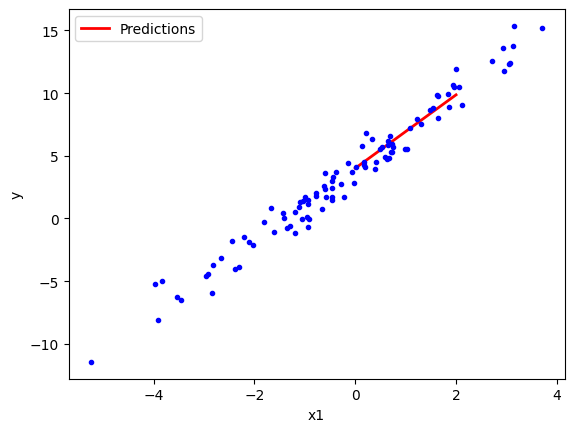

In [18]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
#generate data
np.random.seed(42)
m=100
x=2*np.random.randn(m,1)
y=4+3*x+np.random.randn(m,1)
#bias tearm (x.=1)
#بنضيف عمود كله وحايد على جانب الداتا
x_b=np.c_[np.ones((m,1)),x]
#compute theta using normal equation
#formula :inv(x.T@)@x.T@y
theta_best=np.linalg.inv(x_b.T@x_b)@x_b.T@y
print("Theta(Manual Normal EQ):")
print(theta_best)
#Compute Theta using Scikit-Learn
lin_reg=LinearRegression()
lin_reg.fit(x,y)
print("\nTheta (Scikit-Learn):")
print(f"Intercept (Bias): {lin_reg.intercept_}")
print(f"Coef (Weight): {lin_reg.coef_}")
#Prediction & Plotting
x_new=np.array([[0],[2]])
x_new_b=np.c_[np.ones((2,1)),x_new]
y_predict=x_new_b @ theta_best
plt.plot(x_new, y_predict, "r-", linewidth=2, label="Predictions")
plt.plot(x, y, "b.")
plt.xlabel("x1")
plt.ylabel("y")
plt.legend()
plt.show()

### Task 4: Computational Complexity Stress Test

**الهدف:**
ملاحظة تأثير زيادة عدد الخصائص (Features) على وقت التدريب باستخدام المعادلة الطبيعية.

**المفهوم:**
تعقيد المعادلة الطبيعية هو $O(n^3)$.
هذا يعني أن زيادة عدد الـ Features يؤدي لزيادة وقت التنفيذ بشكل أسي (Exponential) وليس خطي.

**الخطة:**
1. تدريب موديل على داتا صغيرة (1000 features).
2. تدريب موديل على داتا متوسطة (5000 features).
3. مقارنة الوقت المستغرق.

In [19]:
import time

# دالة مساعدة لتوليد داتا وحساب الوقت
def test_complexity(n_features):
    m_instances = 10000
    
    # Generate random data
    X = np.random.rand(m_instances, n_features)
    y = np.random.rand(m_instances, 1)
    
    # Start Timer
    start_time = time.time()
    
    # Run Normal Equation (Using Scikit-Learn SVD underneath)
    lin_reg = LinearRegression()
    lin_reg.fit(X, y)
    
    # End Timer
    end_time = time.time()
    
    return end_time - start_time

print("Testing with 1,000 features...")
time_small = test_complexity(1000)
print(f"Time: {time_small:.4f} seconds")

print("\nTesting with 5,000 features (5x larger)...")
# حسب النظرية، الوقت المفروض يزيد بشكل ملحوظ جداً
time_large = test_complexity(5000)
print(f"Time: {time_large:.4f} seconds")

ratio = time_large / time_small
print(f"\nTime increased by {ratio:.1f}x times!")

Testing with 1,000 features...
Time: 1.2789 seconds

Testing with 5,000 features (5x larger)...
Time: 62.7033 seconds

Time increased by 49.0x times!


### Task 5: Batch Gradient Descent Implementation

**الهدف:**
تطبيق خوارزمية Gradient Descent يدوياً باستخدام المصفوفات (Vectorized implementation) ومقارنة النتيجة بالمعادلة الطبيعية.

**المعادلات:**
1.  **Gradient Vector:**
    $$\nabla_{\theta}MSE(\theta) = \frac{2}{m} \mathbf{X}^T (\mathbf{X} \theta - \mathbf{y})$$
2.  **Update Step:**
    $$\theta^{(\text{next step})} = \theta - \eta \nabla_{\theta}MSE(\theta)$$

**الإعدادات (Hyperparameters):**
* Learning Rate ($\eta$) = 0.1
* Epochs = 1000
* Target: الوصول لنفس قيم $\theta$ التي حسبناها سابقاً (تقريباً 4.215 و 2.770).

In [23]:
#setiting
eta=0.1
n_epochs=1000
m=100
#random Initia;ization
theta=np.random.randn(2,1)
print(f"Starting Random Theta:\n{theta}\n")
print("Traning...")
#loop
for epoch in range(n_epochs):
    #gradint
    gradients=2/m*x_b.T.dot(x_b.dot(theta)-y)
    theta = theta - eta * gradients
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Theta0={theta[0][0]:.4f}, Theta1={theta[1][0]:.4f}")
   
print("\n-----------------------------")
print("Final Theta found by Gradient Descent:")
print(theta)    


Starting Random Theta:
[[-0.3823951 ]
 [ 0.35133394]]

Traning...
Epoch 0: Theta0=0.3885, Theta1=1.8746
Epoch 100: Theta0=4.0074, Theta1=2.9284
Epoch 200: Theta0=4.0074, Theta1=2.9284
Epoch 300: Theta0=4.0074, Theta1=2.9284
Epoch 400: Theta0=4.0074, Theta1=2.9284
Epoch 500: Theta0=4.0074, Theta1=2.9284
Epoch 600: Theta0=4.0074, Theta1=2.9284
Epoch 700: Theta0=4.0074, Theta1=2.9284
Epoch 800: Theta0=4.0074, Theta1=2.9284
Epoch 900: Theta0=4.0074, Theta1=2.9284

-----------------------------
Final Theta found by Gradient Descent:
[[4.00742783]
 [2.92837142]]


### Task 6: Stochastic Gradient Descent (SGD) with Learning Schedule

**الهدف:**
تطبيق SGD يدوياً. في كل خطوة، نختار عينة عشوائية واحدة ونحدث الأوزان. سنستخدم "جدول تعلم" لتقليل حجم الخطوة تدريجياً.

**المعادلات:**
1.  **Learning Schedule:**
    $$\eta(t) = \frac{t_0}{t + t_1}$$
    (كل ما الزمن $t$ يزيد، الـ $\eta$ تقل).

2.  **Gradient (For Single Instance):**
    $$\nabla = 2 \cdot \mathbf{x}_i^T (\mathbf{x}_i \theta - y_i)$$
    *ملحوظة: لا نقسم على $m$ لأننا نحسب الخطأ لعينة واحدة فقط.*

**الإعدادات:**
* Epochs = 50 (لاحظي الفرق! 50 بس بدل 1000 لأننا بناخد خطوات كتير جوه الـ Epoch الواحد).
* Hyperparameters: $t_0 = 5, t_1 = 50$.

In [24]:
import numpy as np
import matplotlib.pyplot as plt

#data generation
x=2*np.random.rand(100,1)
y=4+3*x+np.random.rand(100,1)
x_b=np.c_[np.ones((100,1)),x]
m=100

#hyperparmters for learning schedule
n_epochs=50
t0,t1=5,50

#Learning rate decrese by time
def learning_schedule(t):
    return t0/(t+t1)

#intialization
theta=np.random.randn(2,1)
print(f"Starting Theta:\n{theta}\n")

print("Training with SGD...")
for epoch in range(n_epochs):
    # جوه كل Epoch بنلف عدد m من المرات (عشان نمر على الداتا تقريباً)
    for i in range(m):
        
        # أ. اختيار عينة عشوائية (Random Index)
        random_index = np.random.randint(m)
        xi = x_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        
        # ب. حساب الميل للعينة دي بس
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        
        # ج. حساب الـ Learning Rate الجديد
        eta = learning_schedule(epoch * m + i)
        
        # د. التحديث
        theta = theta - eta * gradients
print("\n-----------------------------")
print("Final Theta found by SGD:")
print(theta)

# مقارنة سريعة
print(f"\nTarget was roughly: 4 and 3")

Starting Theta:
[[-0.94227542]
 [ 0.34203405]]

Training with SGD...

-----------------------------
Final Theta found by SGD:
[[4.39913069]
 [3.07635155]]

Target was roughly: 4 and 3


In [28]:
# Scikit-Learn Implementation
from sklearn.linear_model import SGDRegressor

print("--- Scikit-Learn SGDRegressor ---")

# بنعمل موديل جاهز بنفس الإعدادات
# max_iter=1000: أقصى عدد لفات
# penalty=None: مفيش عقاب (لسه هناخدها في Regularization)
# eta0=0.1: سرعة التعلم المبدئية
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1, random_state=42)

# التدريب (fit)
# ملحوظة: y.ravel() عشان يحول المصفوفة لصف واحد (1D Array) لأن Scikit-Learn بتفضلها كده
sgd_reg.fit(x, y.ravel())

# الطباعة
print(f"Intercept (Theta0): {sgd_reg.intercept_}")
print(f"Coef (Theta1): {sgd_reg.coef_}")

--- Scikit-Learn SGDRegressor ---
Intercept (Theta0): [4.42038965]
Coef (Theta1): [3.08056618]


# Polynomial Regression

## 1. The Concept
What if the data is not a straight line?
If the data is complex (e.g., follows a curve), a simple **Linear Regression** model ($y = \theta_0 + \theta_1 x$) will **underfit** the data.

**The Solution:**
We can still use a linear model to fit nonlinear data by adding **powers of each feature** as new features.
* **Input:** $x$
* **Transformed Input:** $x, x^2$
* **Model Equation:** $y = \theta_0 + \theta_1 x + \theta_2 x^2$

This is called **Polynomial Regression**.

## 2. The Task
We will simulate a scenario where the data follows a quadratic equation:
$$y = 0.5x^2 + x + 2 + \text{Gaussian Noise}$$

### Steps:
1.  **Generate Data:** Create non-linear (quadratic) data with some noise.
2.  **Visualize:** Plot the data to confirm it's not linear.
3.  **Transform:** Use `PolynomialFeatures` (from Scikit-Learn) to add the square of the feature ($x^2$) to the training set.
4.  **Train:** Fit a `LinearRegression` model on the transformed data.
5.  **Verify:** Check if the learned coefficients match the original equation ($0.5, 1, 2$).

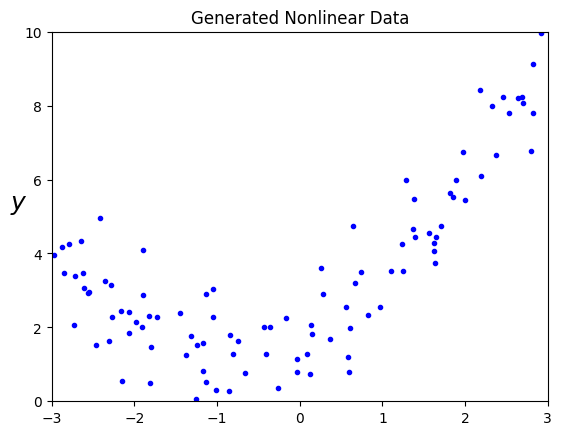

Original X[0]: [-0.75275929]
Transformed X_poly[0]: [-0.75275929  0.56664654]

Model Intercept: [1.78134581]
Model Coefficients: [[0.93366893 0.56456263]]


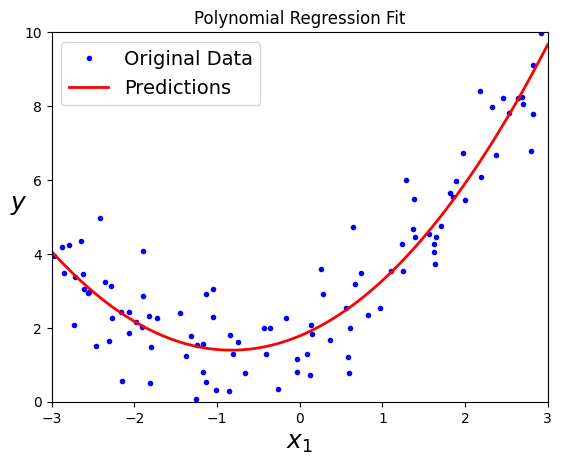

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

#generate data
np.random.seed(42)
m=100
x=6*np.random.rand(m,1)-3
y=0.5*x**2+x+2+np.random.randn(m,1)

#visulaize
plt.plot(x,y,".b")
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.title("Generated Nonlinear Data")
plt.axis([-3, 3, 0, 10])
plt.show()

#tansform
poly_features=PolynomialFeatures(degree=2,include_bias=False)
x_poly=poly_features.fit_transform(x)
print("Original X[0]:", x[0])
print("Transformed X_poly[0]:", x_poly[0])
#train
lin_reg = LinearRegression()
lin_reg.fit(x_poly, y)
#check
print("\nModel Intercept:", lin_reg.intercept_)
print("Model Coefficients:", lin_reg.coef_)
# --- Step 6: Visualize the Prediction Curve ---

# 1. بنعمل بيانات جديدة X مرتبة عشان نرسم خط ناعم
# (من -3 لـ 3، عدد 100 نقطة)
X_new = np.linspace(-3, 3, 100).reshape(100, 1)

# 2. بنحول البيانات الجديدة دي لنفس الشكل (Polynomial)
X_new_poly = poly_features.transform(X_new)

# 3. بنخلي الموديل يتوقع النتايج (y_new)
y_new = lin_reg.predict(X_new_poly)

# 4. بنرسم الرسمة النهائية
plt.plot(x, y, ".b", label="Original Data")      # النقط الزرقاء (البيانات)
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions") # الخط الأحمر (الموديل)

plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([-3, 3, 0, 10])
plt.title("Polynomial Regression Fit")
plt.show()

# Learning Curves

How to tell if the model is Overfitting or Underfitting without visualizing the predictions?
We look at the **Learning Curves**: plots of the model’s performance on the training set and the validation set as a function of the training set size.

### 1. Underfitting Scenario (Linear Regression)
* **Characteristics:** Both training and validation errors are high and reach a plateau. They are close to each other.
* **Meaning:** The model is too simple to capture the data structure.
* **Fix:** Adding more data **will not help**. We need a more complex model.

### 2. Overfitting Scenario (10th-Degree Polynomial)
* **Characteristics:** Training error is very low (model memorizes data), but validation error is high. There is a significant **Gap** between the curves.
* **Meaning:** The model is too complex and fits the noise.
* **Fix:** Add more training data (to close the gap) or reduce model complexity (regularization).

### The Bias/Variance Trade-off
* **High Bias:** Leads to Underfitting.
* **High Variance:** Leads to Overfitting.
* **Goal:** Find the sweet spot (Trade-off) between bias and variance.

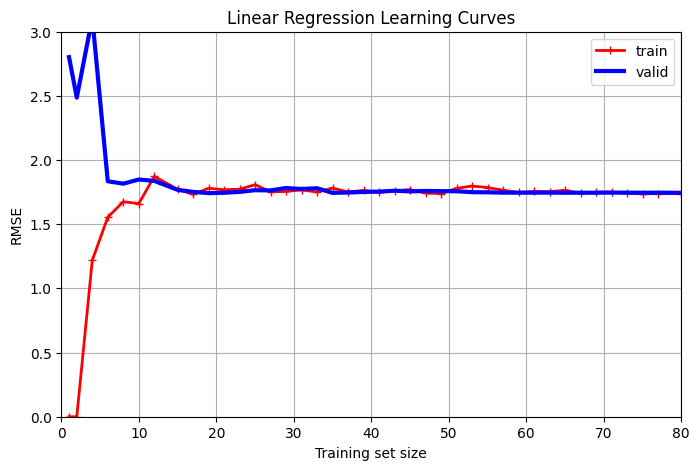

In [3]:
from sklearn.model_selection import learning_curve

#define learning curve
train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), x, y, 
    train_sizes=np.linspace(0.01, 1.0, 40), 
    cv=5,
    scoring="neg_root_mean_squared_error")

#convert scores to errors
train_errors=-train_scores.mean(axis=1)
valid_errors=-valid_scores.mean(axis=1)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.legend(loc="upper right")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.axis([0, 80, 0, 3])
plt.title("Linear Regression Learning Curves")
plt.grid(True)
plt.show()

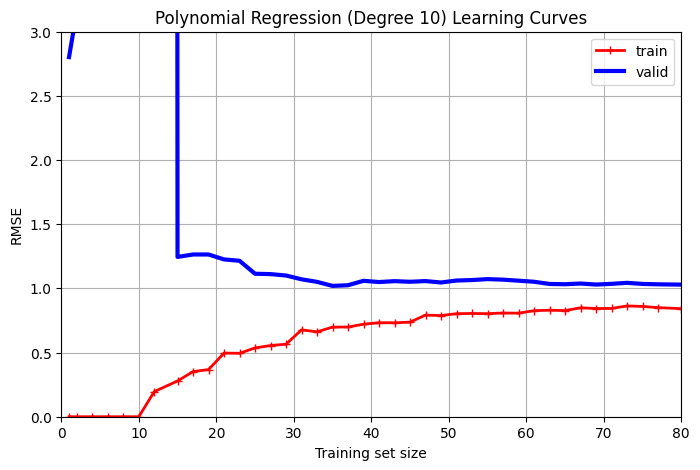

In [5]:
from sklearn.pipeline import make_pipeline

# Create a pipeline for 10th-degree polynomial regression
polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression())

# Calculate learning curves for the complex model
train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, x, y, 
    train_sizes=np.linspace(0.01, 1.0, 40), 
    cv=5,
    scoring="neg_root_mean_squared_error")

# Convert scores to errors
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

# Plotting Figure 4-16
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.legend(loc="upper right")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.axis([0, 80, 0, 3])
plt.title("Polynomial Regression (Degree 10) Learning Curves")
plt.grid(True)
plt.show()

# Ridge Regression (Tikhonov Regularization)

A regularized version of Linear Regression that forces the model weights to be as small as possible to avoid overfitting.

### The Cost Function
$$J(\theta) = MSE(\theta) + \alpha \frac{1}{m} \sum_{i=1}^{n} \theta_i^2$$
* **$\alpha$ (Hyperparameter):** Controls how much we want to regularize the model.
    * $\alpha = 0$: Plain Linear Regression.
    * High $\alpha$: Weights $\approx$ 0 (Flat line).
* **Note:** The bias term ($\theta_0$) is **not** regularized.

### Important Warning
**Feature Scaling is mandatory!** Ridge Regression is sensitive to the scale of input features. Always use `StandardScaler` before using Ridge.

### Implementations in Scikit-Learn
1.  **Closed-form:** `Ridge(solver="cholesky")`
2.  **Iterative:** `SGDRegressor(penalty="l2")`

In [9]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor

# --- Method 1: Closed-form solution using Matrix Factorization (Cholesky) ---
# solver="cholesky" هي طريقة رياضية سريعة لحل المعادلة مباشرة
ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(x, y)
print("Prediction using Ridge (Cholesky):", ridge_reg.predict([[1.5]]))


# --- Method 2: Stochastic Gradient Descent (SGD) ---
# penalty="l2" means we are adding the squared magnitude of coefficients (Ridge)
# Note: We divide alpha by m here purely to match the mathematical formula used by the Ridge class above
# (The book mentions this detail to ensure results are comparable)
sgd_reg = SGDRegressor(penalty="l2", alpha=0.1 / m, tol=None,
                       max_iter=1000, eta0=0.01, random_state=42)

# y.ravel() converts y from column vector to 1D array
sgd_reg.fit(x, y.ravel())
print("Prediction using SGD (l2 penalty):", sgd_reg.predict([[1.5]]))

Prediction using Ridge (Cholesky): [4.82899748]
Prediction using SGD (l2 penalty): [4.82830117]


# Lasso Regression ($\ell_1$ Regularization)

**Least Absolute Shrinkage and Selection Operator**.
Unlike Ridge (which uses squared weights), Lasso adds the sum of the **absolute values** of the weights to the cost function.

### Cost Function
$$J(\theta) = MSE(\theta) + 2\alpha \sum_{i=1}^{n} |\theta_i|$$

### Key Characteristics
1.  **Feature Selection:** Lasso tends to drive the weights of the least important features to exactly **zero**.
2.  **Sparse Model:** The output model often has few non-zero weights (good for models with huge numbers of features).
3.  **Geometry:** The $\ell_1$ penalty creates a diamond shape ($\diamond$) constraint, causing the solution to hit the axes (where weights are zero).

### Important Tip
Lasso gradients do not naturally get smaller as they approach the minimum (unlike Ridge). To prevent the model from "bouncing" around the optimum, you should **gradually reduce the learning rate** during training.

### Implementation
* `Lasso(alpha=0.1)`
* `SGDRegressor(penalty="l1")`

In [10]:
from sklearn.linear_model import Lasso

# تطبيق Lasso باستخدام الكلاس الجاهز
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(x, y)

# التوقع
print("Lasso Prediction:", lasso_reg.predict([[1.5]]))


# ملاحظة الكتاب:
# ممكن نستخدم SGDRegressor برضو بس نغير الـ penalty لـ l1
# sgd_reg = SGDRegressor(penalty="l1", alpha=0.1)

Lasso Prediction: [4.77621741]


# 1. Elastic Net
A middle ground between Ridge and Lasso. It combines both penalties using a mix ratio `l1_ratio` ($r$).

### When to use what?
* **Linear Regression:** Avoid. Always use some regularization.
* **Ridge:** Good default. Use if you want to keep all features.
* **Lasso/Elastic Net:** Use if you suspect some features are useless (need feature selection).
* **Elastic Net > Lasso:** Preferred when features are correlated or when $n_{features} > n_{samples}$, as Lasso can behave erratically.

# 2. Early Stopping
A regularization technique for iterative algorithms (like SGD).
**Idea:** Stop training as soon as the validation error reaches a minimum.

* **"Free Lunch":** Efficient and simple.
* **Implementation:** With SGD, the error curve is bumpy. We train for many epochs, save the model state whenever validation error hits a new record low, and revert to that saved model at the end.
* **Note:** Use `copy.deepcopy` to save the trained parameters, not `sklearn.base.clone`.

In [11]:
from sklearn.linear_model import ElasticNet

# l1_ratio=0.5 means 50% Lasso, 50% Ridge
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(x, y)
print("Elastic Net Prediction:", elastic_net.predict([[1.5]]))

Elastic Net Prediction: [4.78114505]


In [13]:
from copy import deepcopy
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

# 1. Prepare Data (Split into Train and Validation)
# لازم نقسم الداتا عشان Early Stopping بيراقب الـ Validation Error
X_train, X_val, y_train, y_val = train_test_split(x, y.ravel(), test_size=0.2, random_state=42)

# 2. Prepare Pipeline (Poly Features + Scaling)
preprocessing = make_pipeline(
    PolynomialFeatures(degree=90, include_bias=False),
    StandardScaler()
)

X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_val)

# 3. Setup SGD Model
# warm_start=True: بيكمل تعليم من مكان ما وقف المرة اللي فاتت
# penalty=None: مش هنستخدم Ridge ولا Lasso، هنعتمد على التوقيف بس
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)

# 4. Manual Training Loop
n_epochs = 500
best_valid_rmse = float('inf')
best_model = None

for epoch in range(n_epochs):
    # partial_fit: بيدرب على البيانات دي (Epoch واحدة) من غير ما يمسح اللي فات
    sgd_reg.partial_fit(X_train_prep, y_train)
    
    # Check Validation Error
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    #val_error = mean_squared_error(y_val, y_valid_predict, squared=False)-> oldest verion not work now
    mse = mean_squared_error(y_val, y_valid_predict)
    val_error = np.sqrt(mse) # بنحسب الجذر التربيعي يدوي
    
    # لو وصلنا لرقم قياسي جديد، احفظ الموديل
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg) # Important: Deepcopy saves learned weights

print(f"Minimum Validation RMSE reached: {best_valid_rmse}")
# best_model دلوقتي جواه أحسن نسخة وصلنالها

Minimum Validation RMSE reached: 0.7774374754877695
